In [1]:
# --- Cell 1: imports + config  ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel
from task2.training.train_loop import train_model
from task2.methods.dan import DAN, mmd_rbf

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64,
           num_workers=0,          # Windows + Jupyter: workers deadlock on spawn
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=False,
           lambda_mmd=1.0)
DATA_ROOT = '../../datasets/PACS'

In [2]:
# --- Cell 2: loaders (same frozen splits as every other method) ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
print(f"steps/epoch={loaders['steps_per_epoch']}  target imgs={loaders['n_target']}")

steps/epoch=203  target imgs=3929


In [3]:
# --- Cell 3: VERIFICATION  ---
g = torch.Generator().manual_seed(6304)
a = torch.randn(24, 512, generator=g)
b = torch.randn(24, 512, generator=g)          # same distribution as a
c = torch.randn(24, 512, generator=g) + 1.0    # shifted cloud
d = torch.randn(24, 512, generator=g) * 3.0    # same mean, 3x the spread

print(f"identical batch      : {mmd_rbf(a, a).item():.6f}")   # exactly 0
print(f"same distribution    : {mmd_rbf(a, b).item():.6f}")   # small
print(f"shifted mean         : {mmd_rbf(a, c).item():.6f}")   # clearly larger
print(f"same mean, wider     : {mmd_rbf(a, d).item():.6f}")   # also larger:
#   this is the case a plain mean-difference loss would score as ZERO,
#   and it is the whole reason for using MMD instead of ||mu_s - mu_t||^2.
print(f"gradient flows       : {mmd_rbf(a.requires_grad_(), c).requires_grad}")

identical batch      : 0.000000
same distribution    : 0.157357
shifted mean         : 0.889292
same mean, wider     : 0.886479
gradient flows       : True


In [4]:
# --- Cell 4: train DAN ---
set_seed(6304)                    # same seed => identical init to source-only
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = DAN(CFG)

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task2_dan.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=0.7842 loss_cls=0.5545 loss_mmd=0.2296 train_acc=0.8183 | val photo=0.930 art_painting=0.842 cartoon=0.892 mean_f1=0.8880 | 50s
ep02 loss_total=0.4088 loss_cls=0.2183 loss_mmd=0.1905 train_acc=0.9349 | val photo=0.939 art_painting=0.820 cartoon=0.903 mean_f1=0.8874 | 102s
ep03 loss_total=0.3462 loss_cls=0.1687 loss_mmd=0.1775 train_acc=0.9520 | val photo=0.951 art_painting=0.878 cartoon=0.951 mean_f1=0.9263 | 155s
ep04 loss_total=0.3067 loss_cls=0.1301 loss_mmd=0.1766 train_acc=0.9647 | val photo=0.939 art_painting=0.882 cartoon=0.927 mean_f1=0.9158 | 209s
ep05 loss_total=0.2874 loss_cls=0.1081 loss_mmd=0.1793 train_acc=0.9733 | val photo=0.970 art_painting=0.908 cartoon=0.957 mean_f1=0.9449 | 262s
ep06 loss_total=0.2507 loss_cls=0.0775 loss_mmd=0.1732 train_acc=0.9854 | val photo=0.957 art_painting=0.909 cartoon=0.950 mean_f1=0.9387 | 319s
ep07 loss_total=0.2325 loss_cls=0.0643 loss_mmd=0.1682 train_acc=0.9916 | val photo=0.951 art_painting=0.894 cartoon=0.949 mean_f1=

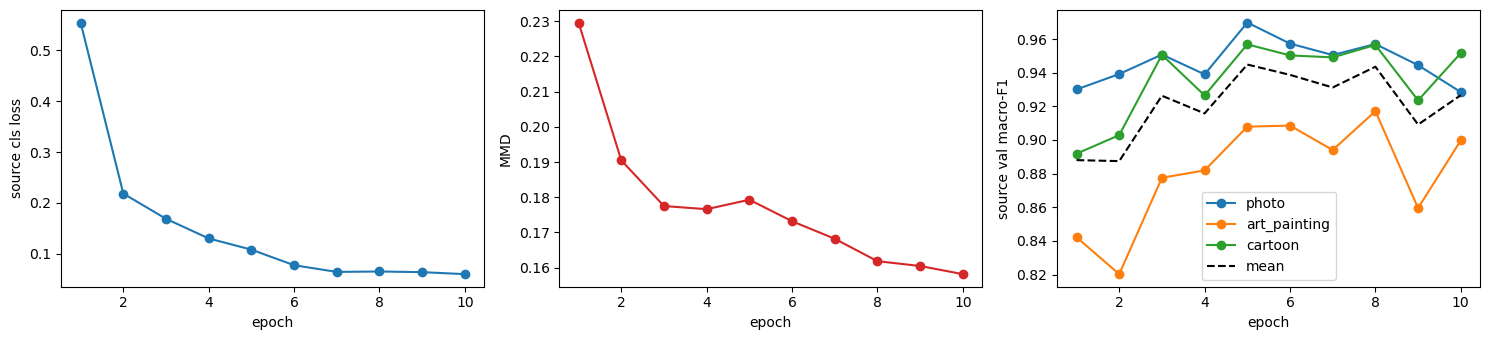

In [5]:
# --- Cell 5: save results + curves (still no target metric anywhere) ---
results = {'step': 'dan', 'seed': 6304, 'method': 'dan',
           'config': CFG, 'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/dan.json')

import matplotlib.pyplot as plt
h = out['history']
ep = [r['epoch'] for r in h]
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].plot(ep, [r['loss_cls'] for r in h], marker='o'); ax[0].set_ylabel('source cls loss')
ax[1].plot(ep, [r['loss_mmd'] for r in h], marker='o', color='tab:red'); ax[1].set_ylabel('MMD')
for d_ in splits['source_domains']:
    ax[2].plot(ep, [r['per_domain'][d_]['macro_f1'] for r in h], marker='o', label=d_)
ax[2].plot(ep, [r['mean_macro_f1'] for r in h], 'k--', label='mean')
ax[2].set_ylabel('source val macro-F1'); ax[2].legend()
for a_ in ax: a_.set_xlabel('epoch')
plt.tight_layout(); plt.savefig('../../report/figures/task2_dan_curves.png', dpi=200)
plt.show()